# Monthly Sunspot Forecasting with Prophet

This notebook builds and evaluates Prophet models for monthly total sunspot observations from the World Data Center SILSO. It compares linear, flat, and logistic growth, several representations of the approximately 11-year solar cycle, and different changepoint settings.

The evaluation uses a chronological holdout period. MAE is the primary selection metric. MAPE excludes observations where the actual sunspot count is zero because percentage error is undefined at zero.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

SOLAR_CYCLE_DAYS = 11 * 365.25
RANDOM_SEED = 42

c:\Abdullah Zahid\Programming\Github\Time-series-forecasting-for-Sunspots\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
def zero_safe_mape(actual, predicted):
    """Return MAPE over observations whose actual value is nonzero."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mask = actual != 0
    return mean_absolute_percentage_error(actual[mask], predicted[mask]) * 100


def detect_time_unit(dates):
    """Infer the time unit and Prophet frequency from timestamp spacing."""
    ordered_dates = (
        pd.Series(pd.to_datetime(dates))
        .dropna()
        .drop_duplicates()
        .sort_values()
    )
    if len(ordered_dates) < 3:
        raise ValueError("At least three unique dates are required to infer frequency.")

    median_days = ordered_dates.diff().dropna().dt.total_seconds().median() / 86_400
    if 0.5 <= median_days <= 1.5:
        return "day", "D", median_days
    if 27 <= median_days <= 32:
        return "month", "MS", median_days
    if 360 <= median_days <= 370:
        return "year", "YS", median_days

    raise ValueError(f"Unsupported or irregular time spacing: {median_days:.2f} days")


def add_bounds(frame, cap):
    bounded = frame.copy()
    bounded["floor"] = 0.0
    bounded["cap"] = cap
    return bounded


def build_model(config, uncertainty_samples=0):
    kwargs = {
        "growth": config["growth"],
        "yearly_seasonality": False,
        "weekly_seasonality": False,
        "daily_seasonality": False,
        "seasonality_mode": "additive",
        "interval_width": 0.80,
        "uncertainty_samples": uncertainty_samples,
    }
    if config["growth"] != "flat":
        kwargs["n_changepoints"] = config["n_changepoints"]
        kwargs["changepoint_prior_scale"] = config["changepoint_prior_scale"]

    model = Prophet(**kwargs)
    model.add_seasonality(
        name="solar_cycle",
        period=config["period_days"],
        fourier_order=config["fourier_order"],
    )
    return model


def evaluate_config(train, test, config):
    cap = max(train["y"].max(), test["y"].max()) * 1.20
    train_input = add_bounds(train, cap) if config["growth"] == "logistic" else train.copy()
    model = build_model(config)
    model.fit(train_input, seed=RANDOM_SEED)

    prediction_input = test[["ds"]].copy()
    if config["growth"] == "logistic":
        prediction_input = add_bounds(prediction_input, cap)
    predicted = model.predict(prediction_input)["yhat"].clip(lower=0)

    return {
        "model": config["name"],
        "growth": config["growth"],
        "period_years": config["period_days"] / 365.25,
        "fourier_order": config["fourier_order"],
        "n_changepoints": config.get("n_changepoints", 0),
        "changepoint_prior_scale": config.get("changepoint_prior_scale", 0.0),
        "MAE": mean_absolute_error(test["y"], predicted),
        "MAPE_nonzero_pct": zero_safe_mape(test["y"], predicted),
        "R2": r2_score(test["y"], predicted),
    }


MODEL_CONFIGS = [
    {
        "name": "linear_10.5y_f5",
        "growth": "linear",
        "period_days": 10.5 * 365.25,
        "fourier_order": 5,
        "n_changepoints": 25,
        "changepoint_prior_scale": 0.05,
    },
    {
        "name": "linear_11y_f10",
        "growth": "linear",
        "period_days": 11 * 365.25,
        "fourier_order": 10,
        "n_changepoints": 50,
        "changepoint_prior_scale": 0.10,
    },
    {
        "name": "linear_11.5y_f15",
        "growth": "linear",
        "period_days": 11.5 * 365.25,
        "fourier_order": 15,
        "n_changepoints": 75,
        "changepoint_prior_scale": 0.20,
    },
    {
        "name": "flat_11y_f10",
        "growth": "flat",
        "period_days": 11 * 365.25,
        "fourier_order": 10,
    },
    {
        "name": "logistic_11y_f10",
        "growth": "logistic",
        "period_days": 11 * 365.25,
        "fourier_order": 10,
        "n_changepoints": 50,
        "changepoint_prior_scale": 0.10,
    },
]

## 2. Load and prepare the data

In [3]:
columns = ["year", "month", "decimal_year", "sunspots", "std_dev", "observations", "status"]
raw = pd.read_csv(RAW_DATA_DIR / "SN_m_tot_V2.0.csv", sep=";", header=None, names=columns)
raw["ds"] = pd.to_datetime(dict(year=raw["year"], month=raw["month"], day=1))
data = (
    raw.loc[raw["sunspots"] >= 0, ["ds", "sunspots"]]
    .rename(columns={"sunspots": "y"})
    .sort_values("ds")
    .drop_duplicates("ds")
    .reset_index(drop=True)
)
data["y"] = data["y"].astype(float)

In [4]:
time_unit, detected_frequency, median_spacing_days = detect_time_unit(data["ds"])

print(f"Rows: {len(data):,}")
print(f"Date range: {data['ds'].min().date()} to {data['ds'].max().date()}")
print(f"Missing values: {data.isna().sum().sum():,}")
print(f"Duplicate dates: {data['ds'].duplicated().sum():,}")
print(f"Detected time unit: {time_unit}")
print(f"Prophet frequency: {detected_frequency}")
print(f"Median timestamp spacing: {median_spacing_days:.2f} days")
data.head()

Rows: 3,280
Date range: 1749-01-01 to 2022-04-01
Missing values: 0
Duplicate dates: 0
Detected time unit: month
Prophet frequency: MS
Median timestamp spacing: 31.00 days


,ds,y
0,1749-01-01,96.700
1,1749-02-01,104.300
2,1749-03-01,116.700
3,1749-04-01,92.800
4,1749-05-01,141.700


In [5]:
data.to_csv(PROCESSED_DATA_DIR / "monthly_sunspots.csv", index=False)
data.describe(include="all")

,ds,y
count,3280,"3,280.000"
mean,1885-08-15 22:47:07.317072896,81.594
min,1749-01-01 00:00:00,0.000
25%,1817-04-23 12:00:00,23.900
50%,1885-08-16 12:00:00,66.850
75%,1953-12-08 18:00:00,122.400
max,2022-04-01 00:00:00,398.200
std,NaN,67.805


## 3. Historical pattern

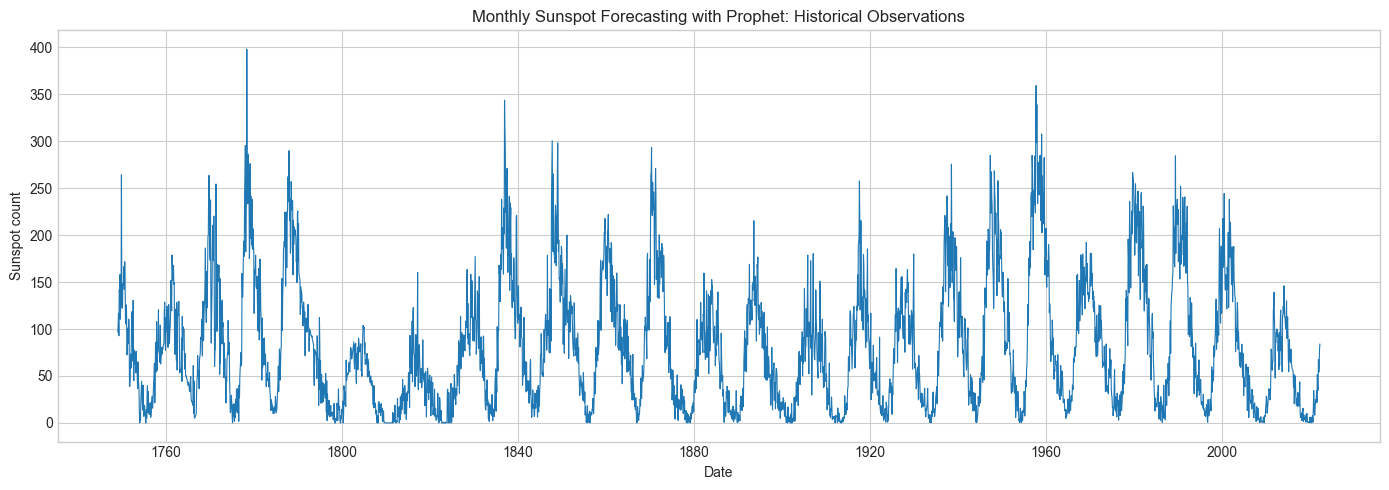

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data["ds"], data["y"], color="#1f77b4", linewidth=0.8)
ax.set(title="Monthly Sunspot Forecasting with Prophet: Historical Observations", xlabel="Date", ylabel="Sunspot count")
plt.tight_layout()
plt.show()

## 4. Chronological validation

The final 24 months form the test set. Every candidate model is trained only on earlier observations, which prevents future values from influencing model selection.

In [7]:
train = data.iloc[:-24].copy()
test = data.iloc[-24:].copy()

In [8]:
print(f"Training rows: {len(train):,} ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"Test rows: {len(test):,} ({test['ds'].min().date()} to {test['ds'].max().date()})")

Training rows: 3,256 (1749-01-01 to 2020-04-01)
Test rows: 24 (2020-05-01 to 2022-04-01)


## 5. Compare Prophet configurations

In [9]:
evaluation_rows = []
for config in MODEL_CONFIGS:
    print(f"Fitting {config['name']}...")
    evaluation_rows.append(evaluate_config(train, test, config))

results = (
    pd.DataFrame(evaluation_rows)
    .sort_values(["MAE", "MAPE_nonzero_pct"])
    .reset_index(drop=True)
)
results

Fitting linear_10.5y_f5...


19:17:09 - cmdstanpy - INFO - Chain [1] start processing
19:17:10 - cmdstanpy - INFO - Chain [1] done processing


Fitting linear_11y_f10...


19:17:10 - cmdstanpy - INFO - Chain [1] start processing
19:17:11 - cmdstanpy - INFO - Chain [1] done processing


Fitting linear_11.5y_f15...


...

Fitting flat_11y_f10...


19:17:12 - cmdstanpy - INFO - Chain [1] start processing
19:17:12 - cmdstanpy - INFO - Chain [1] done processing
19:17:12 - cmdstanpy - INFO - Chain [1] start processing


Fitting logistic_11y_f10...


19:17:13 - cmdstanpy - INFO - Chain [1] done processing


,model,growth,period_years,fourier_order,n_changepoints,changepoint_prior_scale,MAE,MAPE_nonzero_pct,R2
0,linear_11y_f10,linear,11.000,10,50,0.100,12.024,522.045,0.581
1,logistic_11y_f10,logistic,11.000,10,50,0.100,20.627,"1,194.180",0.046
2,flat_11y_f10,flat,11.000,10,0,0.000,22.701,"1,279.630",-0.143
3,linear_11.5y_f15,linear,11.500,15,75,0.200,44.101,"2,355.034",-3.297
4,linear_10.5y_f5,linear,10.500,5,25,0.050,66.756,"3,037.768",-7.976


In [10]:
best_name = results.loc[0, "model"]
best_config = next(config for config in MODEL_CONFIGS if config["name"] == best_name)
print(f"Selected model: {best_name}")
best_config

Selected model: linear_11y_f10


{'name': 'linear_11y_f10',
 'growth': 'linear',
 'period_days': 4017.75,
 'fourier_order': 10,
 'n_changepoints': 50,
 'changepoint_prior_scale': 0.1}

## 6. Validate the selected model

In [11]:
validation_cap = max(train["y"].max(), test["y"].max()) * 1.20
validation_train = add_bounds(train, validation_cap) if best_config["growth"] == "logistic" else train.copy()
validation_model = build_model(best_config)
validation_model.fit(validation_train, seed=RANDOM_SEED)

validation_input = test[["ds"]].copy()
if best_config["growth"] == "logistic":
    validation_input = add_bounds(validation_input, validation_cap)

validation_forecast = validation_model.predict(validation_input)
validation_table = test.copy()
validation_table["predicted"] = validation_forecast["yhat"].clip(lower=0).to_numpy()
validation_table.head()

19:17:22 - cmdstanpy - INFO - Chain [1] start processing
19:17:22 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,predicted
3256,2020-05-01,0.200,17.681
3257,2020-06-01,5.800,17.173
3258,2020-07-01,6.100,16.768
3259,2020-08-01,7.500,16.522
3260,2020-09-01,0.600,16.509


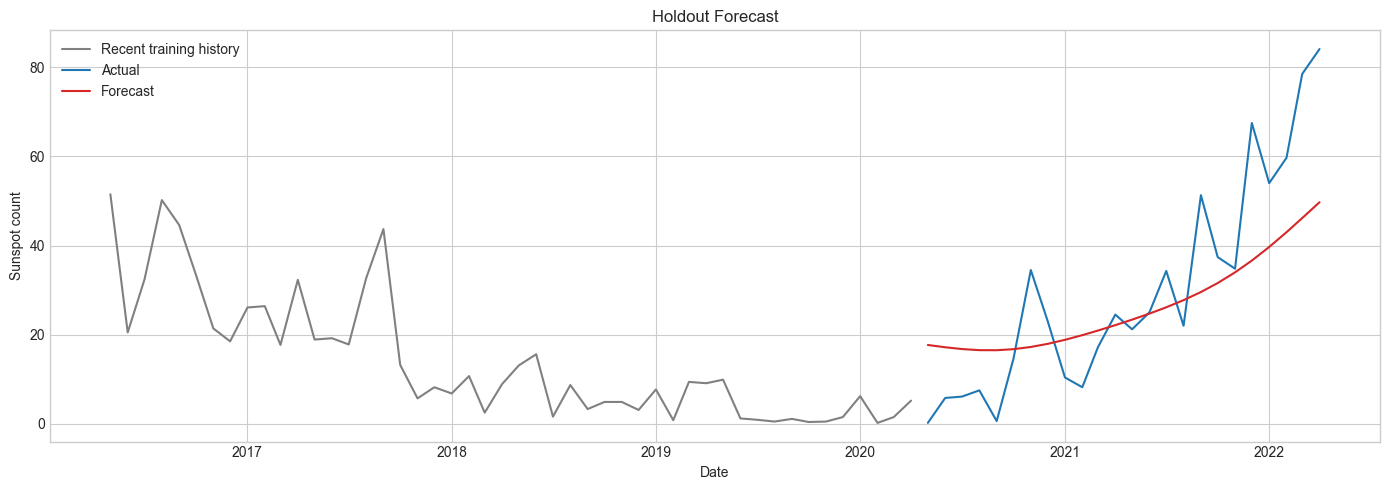

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train["ds"].tail(len(test) * 2), train["y"].tail(len(test) * 2), label="Recent training history", color="#808080")
ax.plot(test["ds"], test["y"], label="Actual", color="#1f77b4")
ax.plot(validation_table["ds"], validation_table["predicted"], label="Forecast", color="#d62728")
ax.set(title="Holdout Forecast", xlabel="Date", ylabel="Sunspot count")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Fit the selected model to the full history

In [13]:
final_cap = data["y"].max() * 1.20
final_training = add_bounds(data, final_cap) if best_config["growth"] == "logistic" else data.copy()
final_model = build_model(best_config, uncertainty_samples=200)
final_model.fit(final_training, seed=RANDOM_SEED)

future = final_model.make_future_dataframe(
    periods=9,
    freq=detected_frequency,
    include_history=False,
)
if best_config["growth"] == "logistic":
    future = add_bounds(future, final_cap)

forecast = final_model.predict(future)
forecast["yhat"] = forecast["yhat"].clip(lower=0)
forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)
forecast["yhat_upper"] = forecast["yhat_upper"].clip(lower=0)

19:17:32 - cmdstanpy - INFO - Chain [1] start processing
19:17:33 - cmdstanpy - INFO - Chain [1] done processing


## 8. Selected future horizons

In [14]:
last_observed = data["ds"].max()
horizon_dates = [last_observed + pd.DateOffset(months=months) for months in [1, 6, 9]]
forecast_table = forecast.loc[forecast["ds"].isin(horizon_dates), ["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_table.insert(0, "horizon_months", [1, 6, 9])
forecast_table

,horizon_months,ds,yhat,yhat_lower,yhat_upper
0,1,2022-05-01,53.564,0.000,124.249
5,6,2022-10-01,65.004,0.000,123.429
8,9,2023-01-01,68.356,8.018,135.570


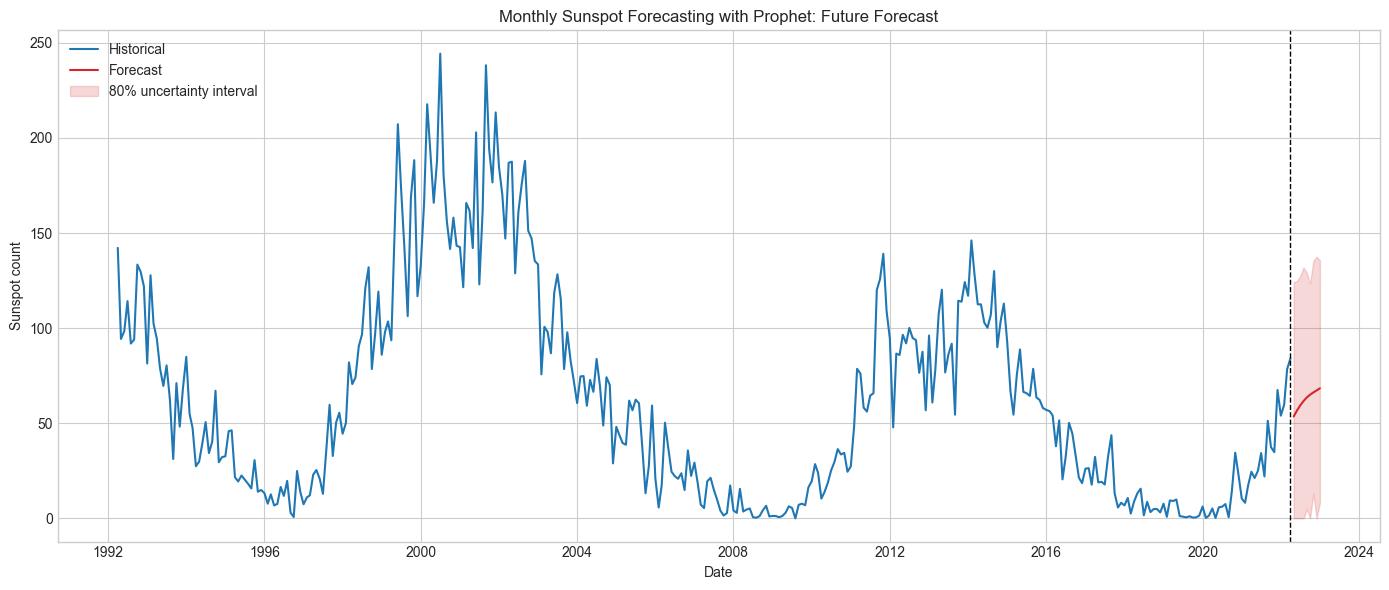

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
history_start = data["ds"].max() - pd.DateOffset(years=30)
recent_history = data[data["ds"] >= history_start]
future_forecast = forecast[forecast["ds"] > data["ds"].max()]

ax.plot(recent_history["ds"], recent_history["y"], label="Historical", color="#1f77b4")
ax.plot(future_forecast["ds"], future_forecast["yhat"], label="Forecast", color="#d62728")
ax.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    color="#d62728",
    alpha=0.18,
    label="80% uncertainty interval",
)
ax.axvline(data["ds"].max(), color="black", linestyle="--", linewidth=1)
ax.set(title="Monthly Sunspot Forecasting with Prophet: Future Forecast", xlabel="Date", ylabel="Sunspot count")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Interpretation and limitations

- The model selection table reports genuinely out-of-sample performance over the most recent 24 months.
- MAE is emphasized because zero sunspot counts make ordinary MAPE undefined. The displayed MAPE uses only nonzero actual observations.
- Prophet provides an interpretable trend-and-seasonality forecast, but solar activity is a complex physical process. Forecast uncertainty increases with the horizon, and these estimates should not be treated as operational space-weather predictions.
- The selected configuration is refitted on the complete observed history before producing the final monthly forecast.